In [1]:
!pip install numpy
!pip install pandas

In [11]:
from google.colab import files
uploaded = files.upload()

Saving Revenue.csv to Revenue.csv


Reshaped Data with All Column Names in One Row:
   Company  Year  Financial Metric  Value
0  Company  Year  Financial Metric  Value


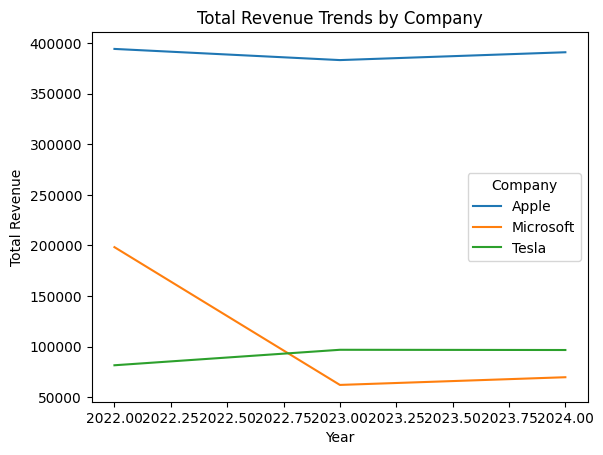

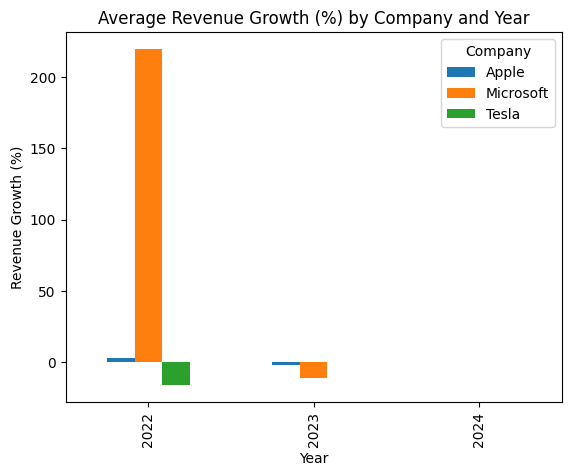

Company Summary:
     Company  Total Revenue  Net Income  Operating Cash Flow   Total Assets  \
0      Apple      1168648.0    290534.0             350948.0  353472.000000   
1  Microsoft       329922.0    118716.0             130179.0  470300.333333   
2      Tesla       274786.0     40015.0              43039.0    5334.666667   

   Total Liabilities  
0      279708.000000  
1      224395.666667  
2        3626.666667  

Year Summary:
   Year  Total Revenue  Net Income  Operating Cash Flow  Total Assets  \
0  2022       674060.0    185128.0         74591.000000      237507.0   
1  2023       542078.0    133839.0         48123.333333      289611.0   
2  2024       557218.0    130298.0         52007.666667      301989.0   

   Total Liabilities  
0      147056.666667  
1      179300.000000  
2      181373.666667  

Data with Year-over-Year Growth:
     Company  Year  Total Revenue  Net Income  Total Assets  \
0  Microsoft  2024        69632.0     24108.0      533898.0   
1  Microsoft  

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset (ensure path is correct)
df = pd.read_csv('Revenue.csv')

# Clean columns that need to be converted to numeric values (e.g., '$' and ',')
df['Total Revenue'] = df['Total Revenue'].replace({'\$': '', ',': ''}, regex=True).astype(float)
df['Net Income'] = df['Net Income'].replace({'\$': '', ',': ''}, regex=True).astype(float)
df['Total Assets'] = df['Total Assets'].replace({'\$': '', ',': ''}, regex=True).astype(float)
df['Total Liabilities'] = df['Total Liabilities'].replace({'\$': '', ',': ''}, regex=True).astype(float)
df['Operating Cash Flow'] = df['Operating Cash Flow'].replace({'\$': '', ',': ''}, regex=True).astype(float)

# Calculate Year-over-Year Changes for Each Financial Metric
df['Revenue Growth (%)'] = df.groupby(['Company'])['Total Revenue'].pct_change() * 100
df['Net Income Growth (%)'] = df.groupby(['Company'])['Net Income'].pct_change() * 100
df['Operating Cash Flow Growth (%)'] = df.groupby(['Company'])['Operating Cash Flow'].pct_change() * 100
df['Total Assets Growth (%)'] = df.groupby(['Company'])['Total Assets'].pct_change() * 100
df['Total Liabilities Growth (%)'] = df.groupby(['Company'])['Total Liabilities'].pct_change() * 100

# Aggregating by 'Company' to get total values (sum of revenue, net income, etc.)
company_summary = df.groupby('Company').agg({
    'Total Revenue': 'sum',
    'Net Income': 'sum',
    'Operating Cash Flow': 'sum',
    'Total Assets': 'mean',
    'Total Liabilities': 'mean'
}).reset_index()

# Aggregating by 'Year' to get total revenue and other metrics across all companies
year_summary = df.groupby('Year').agg({
    'Total Revenue': 'sum',
    'Net Income': 'sum',
    'Operating Cash Flow': 'mean',
    'Total Assets': 'mean',
    'Total Liabilities': 'mean'
}).reset_index()

# Reshaping the data to have column names in one row (using pd.melt)
reshaped_df = pd.melt(df, id_vars=['Company', 'Year'],
                      value_vars=['Total Revenue', 'Net Income', 'Operating Cash Flow',
                                   'Total Assets', 'Total Liabilities', 'Revenue Growth (%)',
                                   'Net Income Growth (%)', 'Operating Cash Flow Growth (%)',
                                   'Total Assets Growth (%)', 'Total Liabilities Growth (%)'],
                      var_name='Financial Metric', value_name='Value')

# Convert the reshaped data into a single row with all column names
reshaped_df_single_row = pd.DataFrame([reshaped_df.columns], columns=reshaped_df.columns)

# Displaying the reshaped data
print("Reshaped Data with All Column Names in One Row:")
print(reshaped_df_single_row)

# Visualizations (optional)
# Plotting total revenue for each company over the years
df.groupby(['Year', 'Company'])['Total Revenue'].sum().unstack().plot(kind='line')
plt.title("Total Revenue Trends by Company")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.show()

# Plotting the revenue growth percentages over the years
df.groupby(['Year', 'Company'])['Revenue Growth (%)'].mean().unstack().plot(kind='bar')
plt.title("Average Revenue Growth (%) by Company and Year")
plt.xlabel("Year")
plt.ylabel("Revenue Growth (%)")
plt.show()

# Print summaries to check the results
print("Company Summary:")
print(company_summary)

print("\nYear Summary:")
print(year_summary)

print("\nData with Year-over-Year Growth:")
print(df)

# Export the aggregated data to CSV for reference
company_summary.to_csv('company_summary.csv', index=False)
year_summary.to_csv('year_summary.csv', index=False)

# Display the entire DataFrame in a more readable format
print("\nComplete Data:")
print(df.to_string(index=False))
